In [1]:
# investigating the impact of self-consumption, i.e., no export, on local voltage. Would it still go above 253?!
# If goes then V-watt is unfair
from Data_query.trino_config import *
import json
import numpy as np
import matplotlib.pyplot as plt
from visualisation import *
import pytz


In [11]:
stop_trino()


Trino service stopping triggered.


In [2]:
num_workers = 8
ensure_trino_running(worker_desired_count = 0, big_worker_desired_count=num_workers)
sleep(30)


Trino service is not running. Starting the service...
Trino service triggered.
Service trino-service is now stable.


In [ ]:
def run_func(args):
    year, month, split_cons = args
    df = iceberg_sql(f"""
                        with data as (
                            select site_id, t_stamp, sum(cast(power*circuit_polarity as decimal(18, 6)))/1000 as P_kW, 
                                    avg(cast(voltage as decimal(18, 6))) as V, circuit_type, ac_capacity_kw
                        from 
                        (select circuit_id, t_stamp, power, energy_reactive, voltage 
                        from ts where year={year} and month={month} and voltage > 0 and voltage < 300 
                        and {split_cons} 
                        ) as ts1
                        inner join (select site_id, circuit_id, circuit_polarity, circuit_type, ac_capacity_kw from meta_up23c 
                        ) as m on ts1.circuit_id = m.circuit_id
                        group by site_id, t_stamp, circuit_type, ac_capacity_kw),
                        data2 as (
                        select site_id, t_stamp, avg(V) as V, ac_capacity_kw,
                        sum(case when circuit_type like 'pv_%' then P_kW  end) as P_pv,
                        sum(case when circuit_type = 'ac_load_net' then P_kW end) as P_net,
                        sum(case when circuit_type not like 'pv_%' and circuit_type != 'ac_load_net' then P_kW  end) as P_other
                        from data
                        group by site_id, t_stamp, ac_capacity_kw)
                        select {year} as year, {month} as month, site_id, count(distinct t_stamp) as n_time
                        from data2
                        where V > 253 and P_net >= 0 and P_pv > 0.16*ac_capacity_kw
                        group by site_id
                
                        """)
                        # 
    
    print(f"Completed year={year}, month={month}, {split_cons.replace('system.bucket(postcode, 16)', 'bucket')}")
    return df

tasks = [(year, month, split_cons) for year in (2024, 2025) for month in range(1, 13) 
         for split_cons in ['system.bucket(postcode, 16) <= 3', '(system.bucket(postcode, 16) > 3 and system.bucket(postcode, 16) <= 7)', 
                            '(system.bucket(postcode, 16) > 7 and system.bucket(postcode, 16) <= 11)', 'system.bucket(postcode, 16) > 11'] ]
        #  for split_cons in ['system.bucket(postcode, 16) <= 7',  'system.bucket(postcode, 16) > 7'] ]
         
df_zero_export = trino_parallel(run_func, tasks, num_workers=num_workers)

Completed year=2024, month=1, (bucket > 3 and bucket <= 7)
Completed year=2024, month=2, bucket > 11
Completed year=2024, month=1, bucket > 11
Completed year=2024, month=1, (bucket > 7 and bucket <= 11)
Completed year=2024, month=2, bucket <= 3
Completed year=2024, month=1, bucket <= 3
Completed year=2024, month=2, (bucket > 3 and bucket <= 7)
Completed year=2024, month=2, (bucket > 7 and bucket <= 11)
Completed year=2024, month=3, (bucket > 3 and bucket <= 7)
Completed year=2024, month=4, bucket <= 3
Completed year=2024, month=3, bucket > 11
Completed year=2024, month=3, (bucket > 7 and bucket <= 11)
Completed year=2024, month=3, bucket <= 3
Completed year=2024, month=4, (bucket > 3 and bucket <= 7)
Completed year=2024, month=4, (bucket > 7 and bucket <= 11)
Completed year=2024, month=5, bucket <= 3
Completed year=2024, month=4, bucket > 11
Completed year=2024, month=5, (bucket > 3 and bucket <= 7)
Completed year=2024, month=5, (bucket > 7 and bucket <= 11)Completed year=2024, month=6

In [4]:
def run_func(args):
    year, month, split_cons = args
    df = iceberg_sql(f"""
                        with data as (
                            select site_id, t_stamp, sum(cast(power*circuit_polarity as decimal(18, 6)))/1000 as P_kW, 
                                    avg(cast(voltage as decimal(18, 6))) as V, circuit_type
                        from 
                        (select circuit_id, t_stamp, power, energy_reactive, voltage 
                        from ts where year={year} and month={month} and voltage > 0 and voltage < 300 
                        and {split_cons} 
                        ) as ts1
                        inner join (select site_id, circuit_id, circuit_polarity, circuit_type from meta_up23c 
                        ) as m on ts1.circuit_id = m.circuit_id
                        group by site_id, t_stamp, circuit_type),
                        data2 as (
                        select site_id, t_stamp, avg(V) as V,
                        sum(case when circuit_type like 'pv_%' then P_kW  end) as P_pv,
                        sum(case when circuit_type = 'ac_load_net' then P_kW end) as P_net,
                        sum(case when circuit_type not like 'pv_%' and circuit_type != 'ac_load_net' then P_kW  end) as P_other
                        from data
                        group by site_id, t_stamp)
                        select {year} as year, {month} as month, site_id, count(distinct t_stamp) as total_time
                        from data2
                        group by site_id
                
                        """)
                        # 
    
    print(f"Completed year={year}, month={month}, {split_cons.replace('system.bucket(postcode, 16)', 'bucket')}")
    return df

tasks = [(year, month, split_cons) for year in (2024, 2025) for month in range(1, 13) 
         for split_cons in ['system.bucket(postcode, 16) <=7 ',  'system.bucket(postcode, 16) > 7'] ]

df_total = trino_parallel(run_func, tasks, num_workers=num_workers)
df_total['total_time'].sum()

Completed year=2024, month=2, bucket <=7 
Completed year=2024, month=1, bucket <=7 
Completed year=2024, month=1, bucket > 7
Completed year=2024, month=2, bucket > 7
Completed year=2024, month=4, bucket <=7 
Completed year=2024, month=3, bucket <=7 
Completed year=2024, month=4, bucket > 7
Completed year=2024, month=3, bucket > 7
Completed year=2024, month=5, bucket <=7 
Completed year=2024, month=5, bucket > 7
Completed year=2024, month=6, bucket <=7 
Completed year=2024, month=6, bucket > 7
Completed year=2024, month=7, bucket <=7 
Completed year=2024, month=7, bucket > 7
Completed year=2024, month=8, bucket <=7 
Completed year=2024, month=8, bucket > 7
Completed year=2024, month=9, bucket > 7
Completed year=2024, month=10, bucket <=7 
Completed year=2024, month=10, bucket > 7
Completed year=2024, month=9, bucket <=7 
Completed year=2024, month=11, bucket <=7 
Completed year=2024, month=11, bucket > 7
Completed year=2025, month=1, bucket <=7 
Completed year=2024, month=12, bucket > 7

1945432335

In [5]:
def run_func(args):
    year, month, split_cons = args
    df = iceberg_sql(f"""
                        with data as (
                            select site_id, t_stamp, sum(cast(power*circuit_polarity as decimal(18, 6)))/1000 as P_kW, 
                                    avg(cast(voltage as decimal(18, 6))) as V, circuit_type, ac_capacity_kw
                        from 
                        (select circuit_id, t_stamp, power, energy_reactive, voltage 
                        from ts where year={year} and month={month} and {split_cons} and voltage > 0 and voltage < 300 
                        ) as ts1
                        inner join (select site_id, circuit_id, circuit_polarity, circuit_type, ac_capacity_kw from meta_up23c 
                        ) as m on ts1.circuit_id = m.circuit_id
                        group by site_id, t_stamp, circuit_type, ac_capacity_kw),
                        data2 as (
                        select site_id, t_stamp, avg(V) as V, ac_capacity_kw,
                        sum(case when circuit_type like 'pv_%' then P_kW  end) as P_pv,
                        sum(case when circuit_type = 'ac_load_net' then P_kW end) as P_net,
                        sum(case when circuit_type not like 'pv_%' and circuit_type != 'ac_load_net' then P_kW  end) as P_other
                        from data
                        group by site_id, t_stamp, ac_capacity_kw)
                        select {year} as year, {month} as month, site_id, count(distinct t_stamp) as total_time_pv
                        from data2
                        where P_pv > 0.16*ac_capacity_kw
                        group by site_id
                
                        """)
                        # 
    
    print(f"Completed year={year}, month={month}, {split_cons.replace('system.bucket(postcode, 16)', 'bucket')}")
    return df

tasks = [(year, month, split_cons) for year in (2024, 2025) for month in range(1, 13) 
         for split_cons in ['system.bucket(postcode, 16) <= 3', '(system.bucket(postcode, 16) > 3 and system.bucket(postcode, 16) <= 7)', 
                            '(system.bucket(postcode, 16) > 7 and system.bucket(postcode, 16) <= 11)', 'system.bucket(postcode, 16) > 11'] ]
        #  for split_cons in ['system.bucket(postcode, 16) <=7 ',  'system.bucket(postcode, 16) > 7'] ]

         
df_total_solar = trino_parallel(run_func, tasks, num_workers=num_workers)
df_total_solar['total_time_pv'].sum()

Completed year=2024, month=2, bucket > 11
Completed year=2024, month=2, (bucket > 3 and bucket <= 7)
Completed year=2024, month=1, bucket > 11
Completed year=2024, month=1, bucket <= 3
Completed year=2024, month=2, bucket <= 3
Completed year=2024, month=1, (bucket > 3 and bucket <= 7)
Completed year=2024, month=1, (bucket > 7 and bucket <= 11)
Completed year=2024, month=2, (bucket > 7 and bucket <= 11)
Completed year=2024, month=4, bucket <= 3
Completed year=2024, month=3, bucket > 11
Completed year=2024, month=4, (bucket > 3 and bucket <= 7)
Completed year=2024, month=4, bucket > 11
Completed year=2024, month=3, bucket <= 3
Completed year=2024, month=3, (bucket > 3 and bucket <= 7)
Completed year=2024, month=3, (bucket > 7 and bucket <= 11)
Completed year=2024, month=5, bucket <= 3
Completed year=2024, month=4, (bucket > 7 and bucket <= 11)
Completed year=2024, month=6, (bucket > 3 and bucket <= 7)
Completed year=2024, month=5, bucket > 11
Completed year=2024, month=6, bucket <= 3
Com

602033526

In [6]:
def run_func(args):
    year, month, split_cons = args
    df = iceberg_sql(f"""
                        with data as (
                            select site_id, t_stamp, sum(cast(power*circuit_polarity as decimal(18, 6)))/1000 as P_kW, 
                                    avg(cast(voltage as decimal(18, 6))) as V, circuit_type
                        from 
                        (select circuit_id, t_stamp, power, energy_reactive, voltage 
                        from ts where year={year} and month={month} and voltage > 0 and voltage < 300 
                        and {split_cons} 
                        ) as ts1
                        inner join (select site_id, circuit_id, circuit_polarity, circuit_type from meta_up23c 
                        ) as m on ts1.circuit_id = m.circuit_id
                        group by site_id, t_stamp, circuit_type),
                        data2 as (
                        select site_id, t_stamp, avg(V) as V,
                        sum(case when circuit_type like 'pv_%' then P_kW  end) as P_pv,
                        sum(case when circuit_type = 'ac_load_net' then P_kW end) as P_net,
                        sum(case when circuit_type not like 'pv_%' and circuit_type != 'ac_load_net' then P_kW  end) as P_other
                        from data
                        group by site_id, t_stamp)
                        select distinct {year} as year, {month} as month, site_id
                        from data2
                        where V > 253
                
                        """)
                        # 
    
    print(f"Completed year={year}, month={month}, {split_cons.replace('system.bucket(postcode, 16)', 'bucket')}")
    return df

tasks = [(year, month, split_cons) for year in (2024, 2025) for month in range(1, 13) 
         for split_cons in ['system.bucket(postcode, 16) <=7 ',  'system.bucket(postcode, 16) > 7'] ]

         
df_highV_sites = trino_parallel(run_func, tasks, num_workers=num_workers)

Completed year=2024, month=1, bucket <=7 
Completed year=2024, month=2, bucket <=7 
Completed year=2024, month=3, bucket <=7 
Completed year=2024, month=2, bucket > 7
Completed year=2024, month=3, bucket > 7
Completed year=2024, month=4, bucket <=7 
Completed year=2024, month=1, bucket > 7
Completed year=2024, month=4, bucket > 7
Completed year=2024, month=5, bucket > 7
Completed year=2024, month=5, bucket <=7 
Completed year=2024, month=6, bucket > 7
Completed year=2024, month=6, bucket <=7 
Completed year=2024, month=7, bucket <=7 
Completed year=2024, month=8, bucket <=7 
Completed year=2024, month=7, bucket > 7
Completed year=2024, month=9, bucket <=7 
Completed year=2024, month=9, bucket > 7
Completed year=2024, month=11, bucket <=7 
Completed year=2024, month=8, bucket > 7
Completed year=2024, month=10, bucket > 7
Completed year=2024, month=12, bucket <=7 
Completed year=2024, month=11, bucket > 7
Completed year=2024, month=10, bucket <=7 
Completed year=2025, month=1, bucket <=7

In [7]:
df_total_solar['site_id'].nunique(), df_total['site_id'].nunique(), df_highV_sites['site_id'].nunique(), df_zero_export['site_id'].nunique()

(17591, 17602, 4530, 621)

In [9]:
df_highV_sites['site_id'].nunique()

4277

In [8]:
df1 = df_zero_export.groupby('site_id').agg({'n_time': 'sum'}).reset_index()
df2 = df_total.groupby('site_id').agg({'total_time': 'sum'}).reset_index()
df0 = df_total_solar.groupby('site_id').agg({'total_time_pv': 'sum'}).reset_index()
df3 = df1.merge(df2, on='site_id')
df3 = df3.merge(df0, on='site_id')
df3['n_time_percentage'] = df3['n_time'] / df3['total_time'] * 100
df3['n_time_percentage_solar'] = df3['n_time'] / df3['total_time_pv'] * 100
df3 = df3.sort_values(by='n_time_percentage_solar', ascending=False).reset_index(drop=True)
df3['s_id'] = df3.index

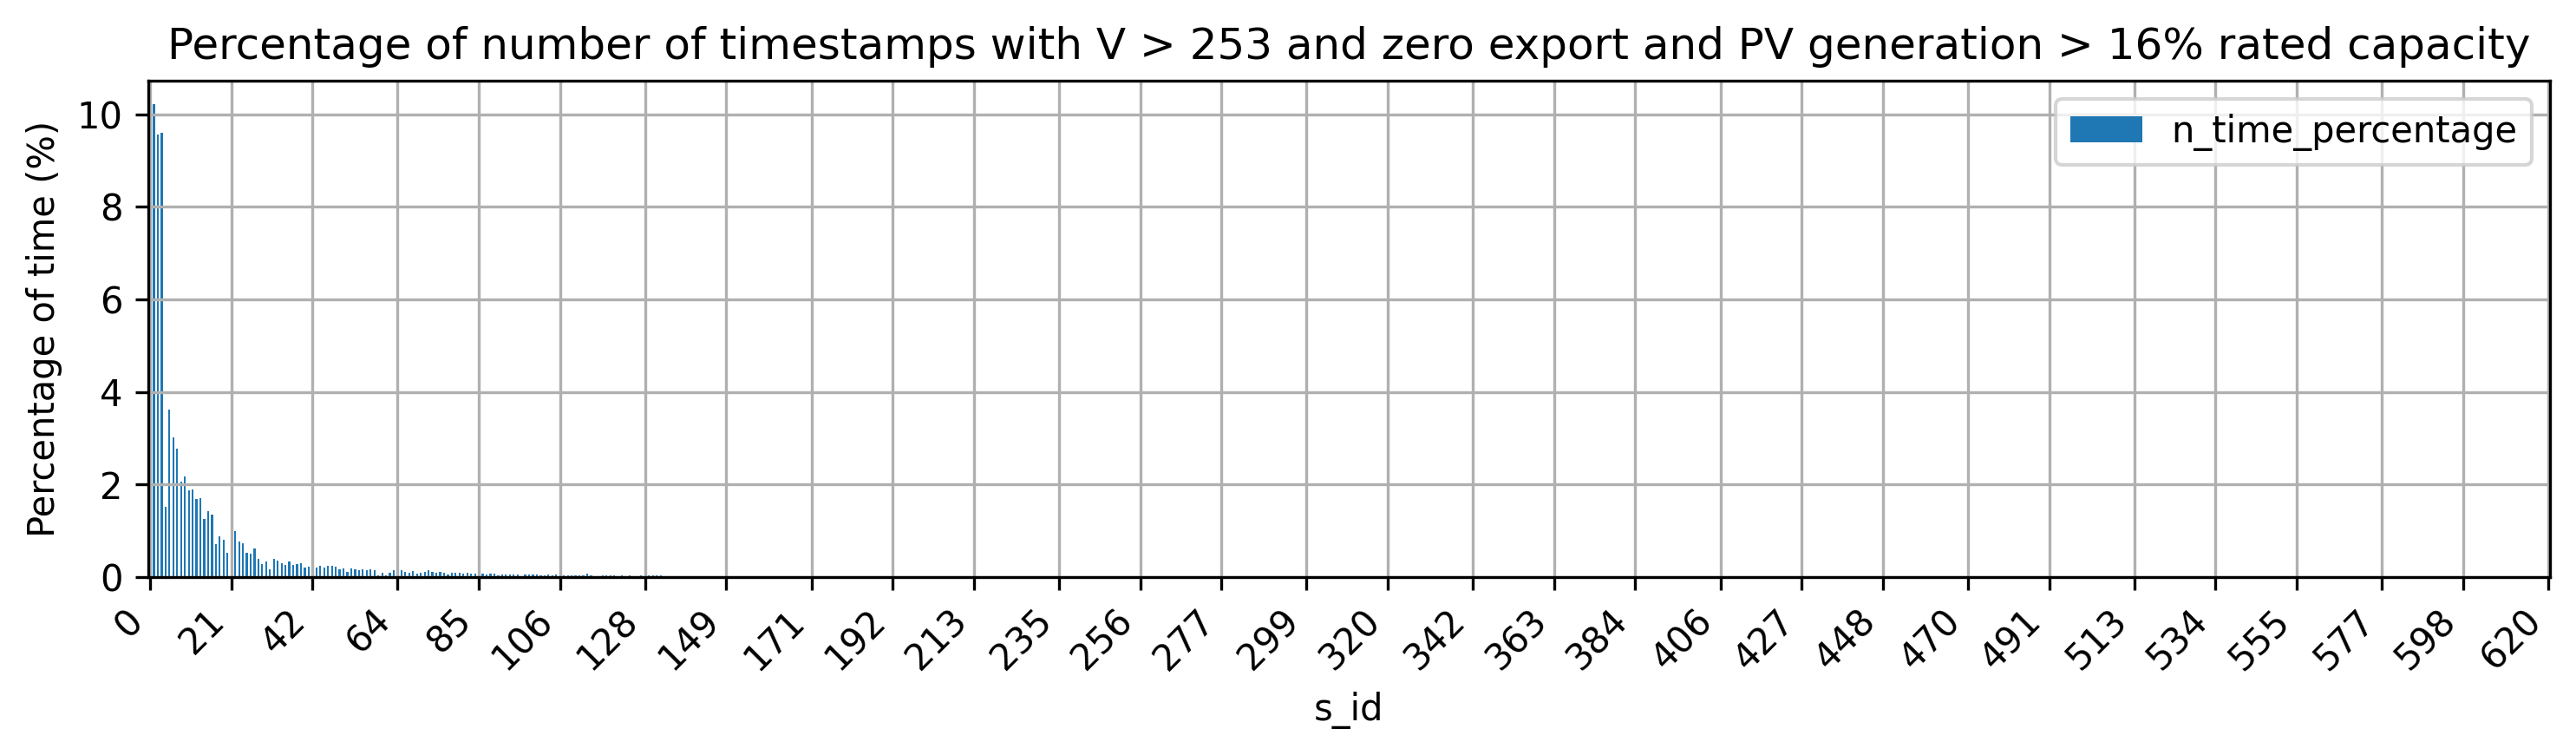

In [9]:
fig, ax = plt.subplots(figsize=(10, 3), dpi=300)

df3.plot(
    kind='bar',
    x='s_id',
    y='n_time_percentage',
    ax=ax,
    title='Percentage of number of timestamps with V > 253 and zero export and PV generation > 16% rated capacity',
    ylabel='Percentage of time (%)',
)

# Set custom tick positions
xticks_positions = np.linspace(0, df3.shape[0]-1, 30, dtype=int)
ax.set_xticks(xticks_positions)

# Optionally label them (if you want specific site IDs)
ax.set_xticklabels(df3['s_id'].iloc[xticks_positions], rotation=45, ha='right')
plt.grid()
plt.tight_layout()
plt.show()

$\frac{N.\,\text{of timestamps with}\, V>253 \,\& \, \text{zero export} \, \& \text{PV > 16\%}}{N.\,\text{of timestamps with}\, \text{PV > 16\%}}$

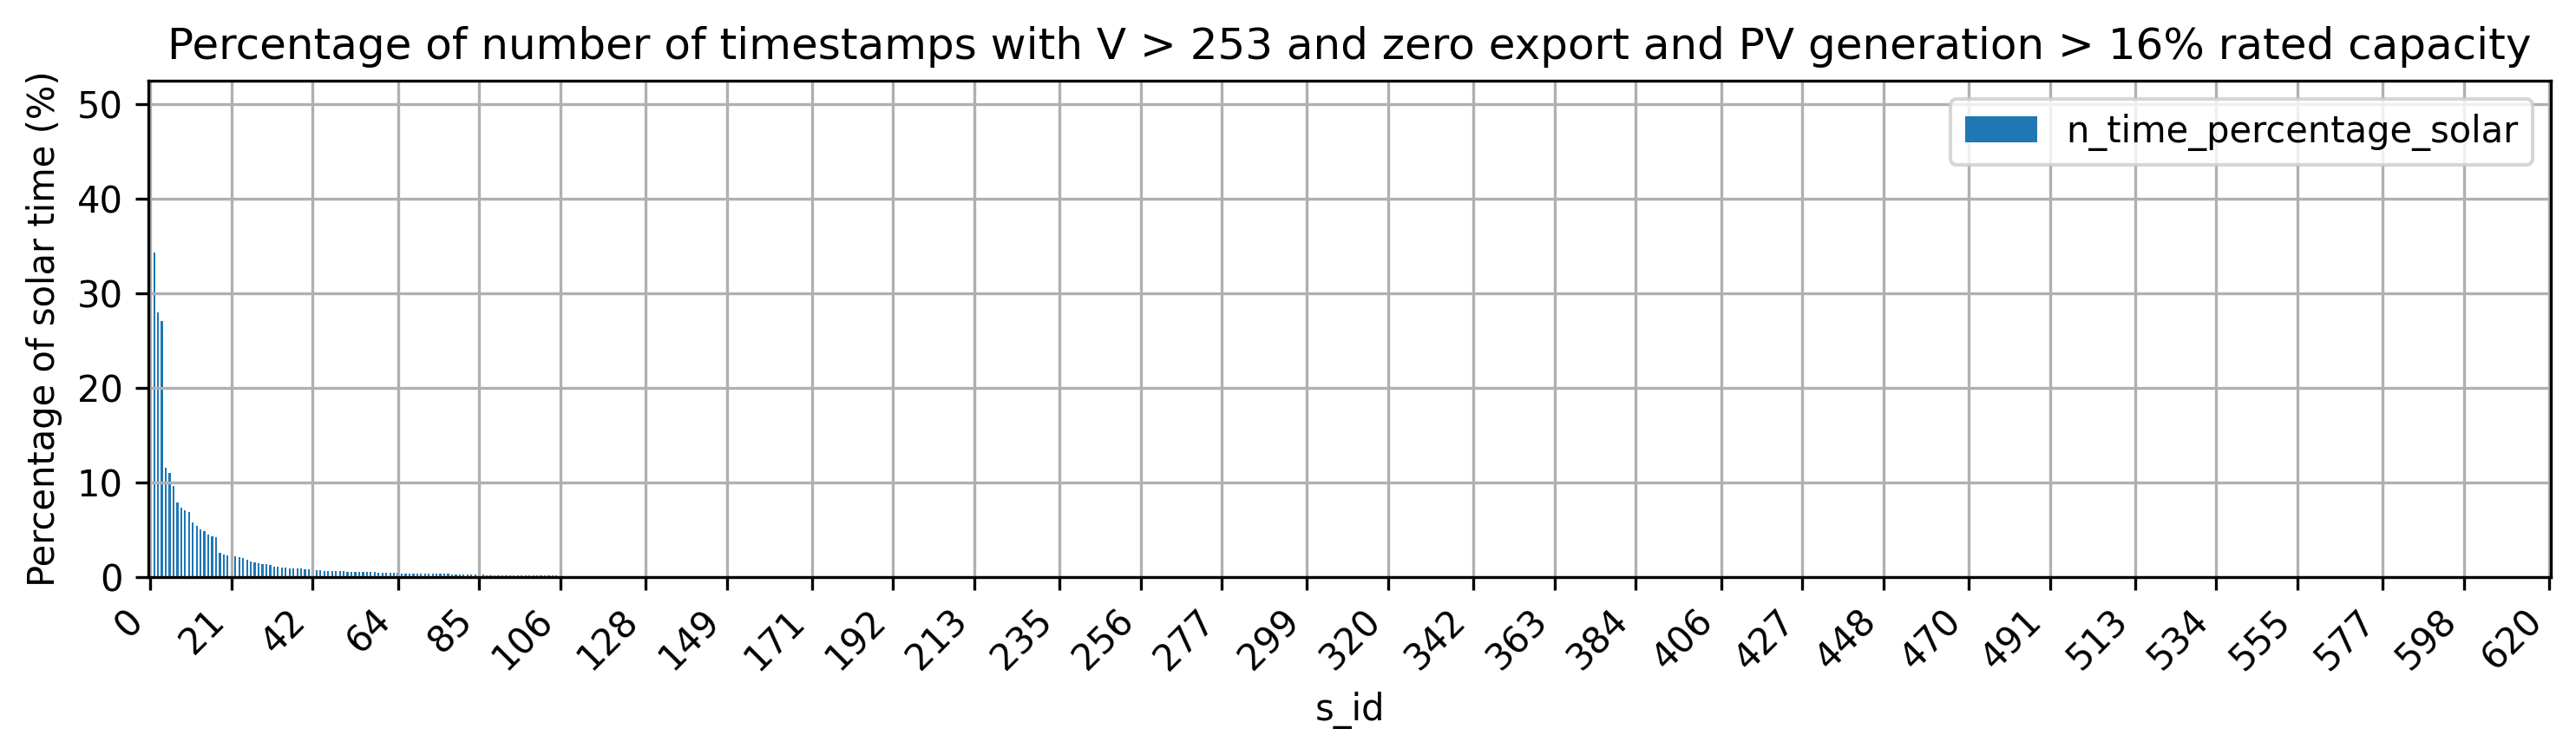

In [10]:
fig, ax = plt.subplots(figsize=(10, 3), dpi=300)

df3.plot(
    kind='bar',
    ax = ax,
    x='s_id',
    y='n_time_percentage_solar',
    title='Percentage of number of timestamps with V > 253 and zero export and PV generation > 16% rated capacity',
    ylabel='Percentage of solar time (%)',
)

# Set custom tick positions
xticks_positions = np.linspace(0, df3.shape[0]-1, 30, dtype=int)
ax.set_xticks(xticks_positions)

# Optionally label them (if you want specific site IDs)
ax.set_xticklabels(df3['s_id'].iloc[xticks_positions], rotation=45, ha='right')
plt.grid()
plt.tight_layout()
plt.savefig("perc_solar.png", dpi=300)
plt.show()

In [12]:
df3

,site_id,n_time,total_time,total_time_pv,n_time_percentage,n_time_percentage_solar,s_id
0,93730315,14941,153567,29901,9.729304,49.968228,0
1,2086897792,15906,155684,46406,10.21685,34.27574,1
2,2089271702,4303,44978,15403,9.566899,27.936116,2
3,1766686290,14183,147782,52416,9.597245,27.058532,3
4,291170555,586,38380,5077,1.526837,11.542249,4
...,...,...,...,...,...,...,...
616,1455712963,1,155441,56369,0.000643,0.001774,616
617,678313347,1,155410,56762,0.000643,0.001762,617
618,462279429,1,155148,57907,0.000645,0.001727,618
619,1105875575,1,155222,58800,0.000644,0.001701,619


In [20]:
iceberg_sql(f"""select site_id  from meta_up23c
            where site_id not in (select site_id from meta_up23c  
            where 
             circuit_type  = 'ac_load_net')
            group by site_id
            having count(distinct circuit_type) > 1
            """)

,site_id
0,636269142
1,1973392206
2,740688650
3,206138330
4,1326927463
...,...
123,563737747
124,1712479461
125,1513947004
126,679670116


In [60]:
iceberg_sql(f"""select circuit_id, circuit_type, ac_capacity_kw, min_time, max_time, distance_km from meta_up23c
            where site_id = 292194641
            """)

,circuit_id,circuit_type,ac_capacity_kw,min_time,max_time,distance_km
0,500024,ac_load_net,10.0,2024-01-01,2025-03-12 05:25:00,0.0
1,500025,pv_site_net,10.0,2024-01-01,2025-03-12 05:25:00,0.0


In [69]:
site_id = 292194641
year, month = 2024, 1
df = iceberg_sql(f"""with data as (select t_stamp, circuit_type, sum(power*circuit_polarity/1000) as P_kw 
                 from ts inner join meta_up23c as m on ts.circuit_id = m.circuit_id
                 where site_id = {site_id} and year = {year} and month = {month} 
                 group by t_stamp, circuit_type)

                  select  *
                 from data 
""")
df['t_stamp'] = pd.to_datetime(df['t_stamp']).dt.tz_localize('utc').dt.tz_convert(pytz.FixedOffset(10*60))

In [51]:
df

,t_stamp,circuit_type,P_kw
0,2024-01-01 16:25:00+10:00,pv_site_net,3.120247
1,2024-01-01 17:10:00+10:00,pv_site_net,2.038073
2,2024-01-01 17:50:00+10:00,pv_site_net,0.463183
3,2024-01-01 19:15:00+10:00,pv_site_net,-0.008517
4,2024-01-01 19:50:00+10:00,pv_site_net,-0.008520
...,...,...,...
26494,2024-02-01 08:30:00+10:00,pv_site_net,2.020520
26495,2024-02-01 08:40:00+10:00,pv_site_net,2.885933
26496,2024-02-01 08:45:00+10:00,pv_site_net,2.805413
26497,2024-02-01 09:10:00+10:00,pv_site_net,5.816260


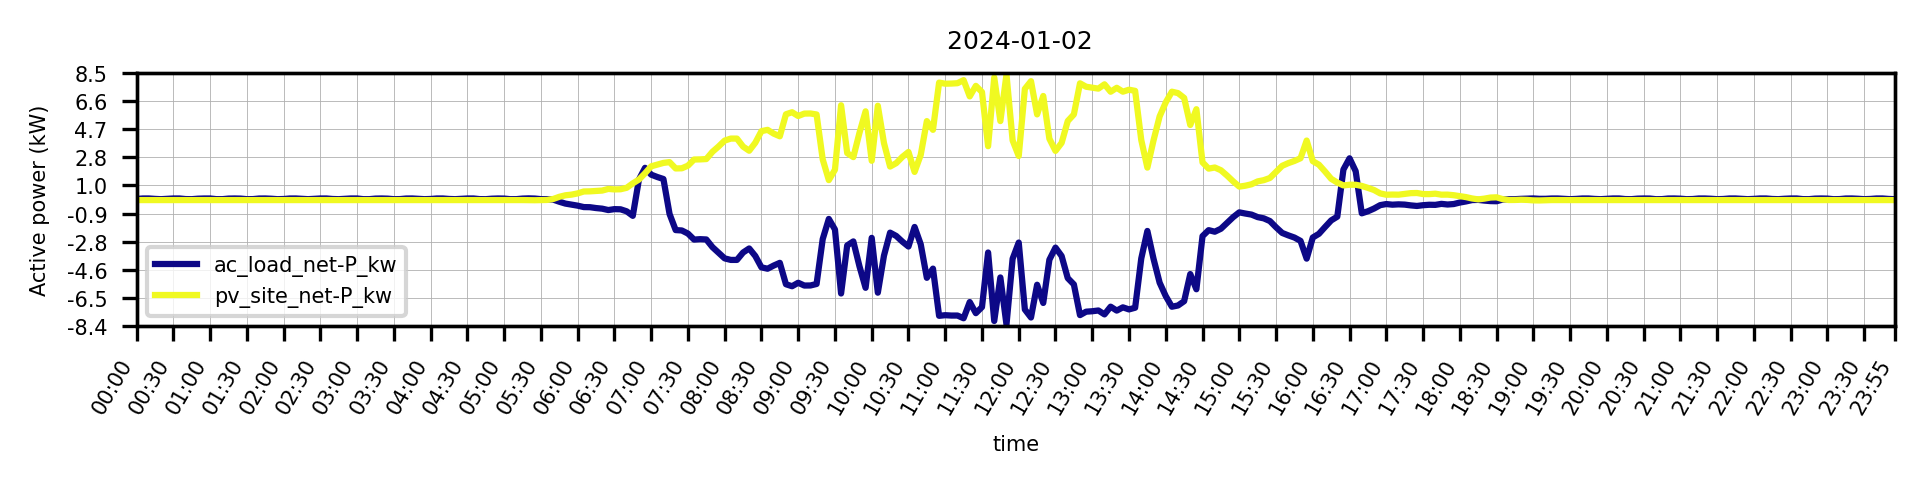

In [70]:
start_time = '2024-01-2 00:00:00+10:00'	 # In sydney local time
end_time =   '2024-01-3 00:00:00+10:00'	 # In sydney local time


num_ticks = 24*2+1
save_as = ''
x_label = 'time'
y_labels = ['Active power (kW)']
plt_config = {'P_kw': [0, 0, '-', None, None]}

color_nights=False
# color_by = 'group'
color_by = 'attribute'
ax_digit = '1.1f'
a=my_plot4(start_time, end_time, df, plt_config=plt_config, ax_digit= ax_digit,
          group_attr='circuit_type', time_attr='t_stamp', color_nights=color_nights,cmap='plasma',
          figsize=[16/2.54,1.5],  same_scale=1, fontsize=5, fontname='DejaVu Sans', plot_total=False, plot_total_func=['sum', [lambda x: max(x), 'max']], 
          num_ticks=num_ticks, num_yticks=10, dpi=300,  x_format= '%H:%M', 
           legend_loc=['lower left', 'upper right'], x_label=x_label, y_labels=y_labels, color_by=color_by,
plot_period=np.timedelta64(1, 'D'), save_as=save_as, rotation = 60, step=0, gridwidth=[0.2, .2], legend_join='-', title='', 
legend_i=0, title_i=0, only1title=0, onlyntime=0)
a.do()

In [97]:
200/18000*100

1.1111111111111112

In [92]:
df3

,site_id,n_time,total_time,n_time_percentage,s_id
0,1176153801,12181,77804,15.656007,0
1,334789519,8839,57954,15.251751,1
2,609112926,17197,146027,11.776589,2
3,432538402,1481,13860,10.685426,3
4,285085090,7406,72829,10.169026,4
...,...,...,...,...,...
1074,111215805,1,155677,0.000642,1074
1075,359525384,1,155729,0.000642,1075
1076,586081492,1,155737,0.000642,1076
1077,586892372,1,155762,0.000642,1077


In [ ]:
iceberg_sql(f"""select  circuit_id, t_stamp
            from ts 
            where year=2024 and month=1 and is_pv=True 
            group by circuit_id, t_stamp
            having count(t_stamp) > 1
            limit 10
            """)


,circuit_id,t_stamp


In [4]:
np.sqrt(100 - 16)

np.float64(9.16515138991168)

In [5]:
iceberg_sql(f"""select *
            from ts 
            where year=2024 and month=10 and is_pv=True 
            and circuit_id = 373631 and t_stamp = TIMESTAMP '2024-10-16 01:20:00'
            """)


,circuit_id,t_stamp,power,energy,energy_reactive,energy_import,energy_export,energy_reactive_import,energy_reactive_export,power_factor,voltage,current,year,month,is_pv,postcode
0,373631,2024-10-16 01:20:00,6904.5267,575.3772,13.1731,575.3772,0.0,13.1731,0.0,0.999476,242.4,30.338,2024,10,True,5244


In [45]:
hive_sql(f"""select *
            from ts 
            where year=2024 and month=10 and is_pv=True 
            and circuit_id = 373631 and t_stamp = TIMESTAMP '2024-10-16 01:20:00'
            """)


,circuit_id,t_stamp,power,energy,energy_reactive,energy_import,energy_export,energy_reactive_import,energy_reactive_export,power_factor,voltage,current,year,month,is_pv
0,373631,2024-10-16 01:20:00,6904.5267,575.3772,13.1731,575.3772,0.0,13.1731,0.0,0.999476,242.4,30.338,2024,10,True


In [94]:
hive_sql(f"""select count( t_stamp) from ts where year=2024 and month=12 and is_pv=True limit 10""")


,_col0
0,352660646


In [75]:
iceberg_sql(f"""with data as (
                        select site_id, t_stamp, sum(power*circuit_polarity/1000) as P_kW, 
                            sum(energy_reactive*circuit_polarity/1000*12) as Q_kvar, 
                                avg(voltage) as V, ac_capacity_kw
                    from 
                    (select circuit_id, t_stamp, power, energy_reactive, voltage 
                    from ts where year=2024 and month=11 and is_pv=True and voltage > 0 and voltage < 300) as ts1
                    inner join meta_up23c as m on ts1.circuit_id = m.circuit_id
                    group by site_id, t_stamp, ac_capacity_kw)
                    select * from data limit 1000
                    """)

,site_id,t_stamp,P_kW,Q_kvar,V,ac_capacity_kw
0,1555410224,2024-11-30 23:35:00,2.895290,-0.442740,242.20,10.0
1,1555410224,2024-11-30 17:35:00,-0.004147,0.059066,241.75,10.0
2,1555410224,2024-11-30 15:15:00,-0.004130,0.060280,244.10,10.0
3,1555410224,2024-11-30 12:55:00,-0.004173,0.059630,242.85,10.0
4,1555410224,2024-11-30 05:15:00,5.620537,-1.619330,245.75,10.0
...,...,...,...,...,...,...
995,1555410224,2024-11-11 06:10:00,3.182053,-0.759553,243.25,10.0
996,1555410224,2024-11-11 03:10:00,5.209433,-1.774690,246.35,10.0
997,1555410224,2024-11-11 01:50:00,5.021500,-1.868400,245.60,10.0
998,1555410224,2024-11-11 00:30:00,5.280233,-1.912177,246.80,10.0


In [ ]:
iceberg_sql(f"""with data as (
                        select site_id, t_stamp, sum(power*circuit_polarity/1000) as P_kW, 
                            sum(energy_reactive*circuit_polarity/1000*12) as Q_kvar, 
                                avg(voltage) as V, ac_capacity_kw
                    from ts as ts1
                    inner join meta_up23c as m on ts1.circuit_id = m.circuit_id
                        where year=2024 and month=11 and ts1.is_pv=True and voltage > 0 and voltage < 300
                    group by site_id, t_stamp, ac_capacity_kw
                   )
                    select * from data limit 10
                    """)

,site_id,t_stamp,P_kW,Q_kvar,V,ac_capacity_kw
0,1555410224,2024-11-30 21:35:00,1.768553,-0.424880,241.65,10.0
1,1555410224,2024-11-30 20:35:00,0.784443,-0.189520,241.05,10.0
2,1555410224,2024-11-30 17:15:00,-0.004183,0.060497,244.55,10.0
3,1555410224,2024-11-30 12:15:00,-0.004193,0.059810,242.95,10.0
4,1555410224,2024-11-30 07:35:00,1.148700,0.082717,240.45,10.0
...,...,...,...,...,...,...
995,1555410224,2024-11-11 16:30:00,-0.004370,0.059200,241.70,10.0
996,1555410224,2024-11-11 14:50:00,-0.004410,0.060097,243.20,10.0
997,1555410224,2024-11-11 13:10:00,-0.004437,0.059113,241.65,10.0
998,1555410224,2024-11-11 05:10:00,6.672080,-1.785070,246.20,10.0


In [65]:
iceberg_sql("select * from meta_up23c limit 2")

,site_id,state,postcode,longitude,latitude,dnsp_name,dc_capacity_kw,ac_capacity_kw,export_limit_kw,monitoring_start,...,circuit_type,is_pv,min_time,max_time,v_95,v_05,m_id,n_long,n_lat,distance_km
0,1944472430,NSW,2502,150.85,-34.47,Endeavour,5.18,5.0,3.0,2021-08-09,...,pv_site_net,True,2024-07-23 04:45:00,2024-07-24 07:05:00,244.3,238.65,M43,150.84,-34.46,1.569777
1,1944472430,NSW,2502,150.85,-34.47,Endeavour,5.18,5.0,3.0,2021-08-09,...,ac_load_net,False,2024-07-23 04:45:00,2024-07-24 07:05:00,244.3,238.65,M43,150.84,-34.46,1.569777


In [18]:
iceberg_sql("""
            with data as (
                select ts.circuit_id, t_stamp, power as P_kW, 
                       energy_reactive*circuit_polarity/1000*12 as Q_kvar, voltage as V
            from ts left join meta_up23c as m on ts.circuit_id = m.circuit_id
            where year=2024 and month=1 and ts.is_pv=True and ts.circuit_id = 467634)
            select * from data order by t_stamp limit 10
            """)

,circuit_id,t_stamp,P_kW,Q_kvar,V
0,467634,2024-01-01 00:00:00,4473.9233,None,241.45
1,467634,2024-01-01 00:05:00,4523.3200,None,241.25
2,467634,2024-01-01 00:10:00,4535.8167,None,241.65
3,467634,2024-01-01 00:15:00,4589.9300,None,242.35
4,467634,2024-01-01 00:20:00,4619.6267,None,241.65
5,467634,2024-01-01 00:25:00,4716.0133,None,241.90
6,467634,2024-01-01 00:30:00,4767.7167,None,242.15
7,467634,2024-01-01 00:35:00,4758.5533,None,242.00
8,467634,2024-01-01 00:40:00,4803.2267,None,242.10
9,467634,2024-01-01 00:45:00,4833.1000,None,243.00


In [ ]:
iceberg_sql("""
            select postcode, count(*) as n from meta_up23c 
            group by postcode
            order by n desc
            """).plot.hist(bins=50)

,postcode,n
0,4740,1690
1,2570,718
2,4814,553
3,4818,507
4,4655,493
...,...,...
1672,3418,1
1673,2623,1
1674,5415,1
1675,4303,1


In [38]:
iceberg_sql("""
            select distinct circuit_type from meta_up23c 
            where circuit_type like '%ac%'
            """)

,circuit_type
0,ac_load_net
1,ac_load
2,load_machine


In [30]:
iceberg_sql("""
            select distinct site_id from meta_up23c 
            where postcode is null
            """)

,site_id


In [ ]:
'site_id', 'state', 'postcode', 'longitude', 'latitude', 'dnsp_name',
       'dc_capacity_kw', 'ac_capacity_kw', 'export_limit_kw',
       'monitoring_start', 'inverter_count', 'pv_install_date', 'manufacturer',
       'model', 'ac_capacity_kw_json', 'device_id', 'circuit_id',
       'device_type', 'circuit_polarity', 'circuit_type', 'is_pv', 'min_time',
       'max_time', 'v_95', 'v_05', 'v_99', 'v_01', 'voltage_class', 'm_id',
       'n_long', 'n_lat', 'distance_km'